In [1]:
# === Mount Google Drive and install dependencies ===
from google.colab import drive
drive.mount("/content/drive")
!pip install -r /content/drive/MyDrive/iris/requirements.txt -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 03 — J3: Feature Inspection

**Purpose:** Determine whether the SAE learned interpretable, injection-sensitive
features — the true test of whether this project direction is viable.

**Context:** J2 did not meet its formal thresholds (reconstruction ratio 0.16,
sparsity 28%), but the SAE captures 84% of activation variance. The question
is no longer "did we hit arbitrary numbers?" but "did the SAE learn features
that are functionally useful for injection detection?"

**Prerequisites:**
- Notebook 02 completed (SAE trained)
- `checkpoints/sae_d6144_lambda1e-04.pt` exists
- `checkpoints/j2_activations.npz` exists
- `data/processed/iris_dataset_balanced.json` exists

**J3 Pass Criterion (Design Document §6.1):**
For the top 20 most injection-sensitive features, examine top-10 activating
prompts. At least 5 features must show a clear, interpretable pattern.

**Outputs:**
- `results/figures/j3_sensitivity_distribution.png`
- `results/figures/j3_top_features_bar.png`
- `results/metrics/j3_feature_inspection.json`
- Feature dashboards printed inline for manual review

In [2]:
# === Setup ===
import sys
import os

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = "/content/drive/MyDrive/iris" if IN_COLAB else os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.utils.helpers import set_seed, get_device
set_seed(42)
device = get_device()

Using GPU: Tesla T4


## Step 1: Load Saved Artifacts

We load three things from previous notebooks:
1. The balanced dataset (for prompt texts and labels)
2. The cached activations (for the layer we trained on)
3. The trained SAE checkpoint

In [3]:
# === Load dataset ===
from src.data.dataset import IrisDataset

dataset = IrisDataset.load("data/processed/iris_dataset_balanced.json")
dataset.summary()

texts = dataset.texts
labels = dataset.labels

Loaded 1000 examples from data/processed/iris_dataset_balanced.json
Total examples: 1000
  Labels:     {0: 500, 1: 500}
  Sources:    {'alpaca': 500, 'deepset_prompt_injections': 203, 'synthetic': 297}
  Categories: {'instruction': 500, 'mixed': 203, 'extraction': 74, 'roleplay': 74, 'override': 75, 'indirect': 74}


In [4]:
# === Load activations ===
import numpy as np

data = np.load("checkpoints/j2_activations.npz")
# Load the layer that J2 trained on. Check j2_evaluation.json for
# which layer was used, or look at the J2 notebook output.
# We load all layers so we can pick the right one.
activations = {i: data[f'layer_{i}'] for i in range(12)}
saved_labels = data['labels']

# Verify labels match the dataset
assert np.array_equal(saved_labels, np.array(labels)), \
    "Label mismatch between saved activations and dataset!"
print(f"Loaded activations for {len(saved_labels)} examples across 12 layers")

Loaded activations for 1000 examples across 12 layers


In [5]:
# === Load trained SAE ===
import torch
import json
from pathlib import Path
from src.sae.architecture import SparseAutoencoder

# Find the SAE checkpoint — look for the one with 6144 features
checkpoint_path = Path("checkpoints/sae_d6144_lambda1e-04.pt")
if not checkpoint_path.exists():
    # Fall back to scanning for any SAE checkpoint
    candidates = list(Path("checkpoints").glob("sae_*.pt"))
    print(f"Expected checkpoint not found. Available: {candidates}")
    checkpoint_path = candidates[0] if candidates else None
    assert checkpoint_path, "No SAE checkpoint found! Run notebook 02 first."

checkpoint = torch.load(checkpoint_path, map_location=device)
config = checkpoint['config']
print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Config: {config}")

# Reconstruct the SAE with the same architecture
sae = SparseAutoencoder(
    d_input=config['d_input'],
    expansion_factor=config['expansion_factor'],
    sparsity_coeff=config.get('sparsity_coeff', 1e-4),
)
sae.load_state_dict(checkpoint['model_state_dict'])
sae = sae.to(device)
sae.eval()

TRAIN_LAYER = 0  # Update this if J2 used a different layer
print(f"\nSAE: {sae.d_sae} features, trained on layer {TRAIN_LAYER}")

Loaded checkpoint: checkpoints/sae_d6144_lambda1e-04.pt
Config: {'d_input': 768, 'expansion_factor': 8, 'sparsity_coeff': 0.0001, 'lr': 0.0003, 'batch_size': 256, 'epochs': 100, 'seed': 42, 'n_samples': 1000}

SAE: 6144 features, trained on layer 0


## Step 2: Compute Feature Activations and Sensitivity Scores

For every prompt in the dataset, we run the SAE encoder to get the
6144-dimensional sparse feature vector. Then we compute each feature's
injection-sensitivity: the difference in mean activation between
injection and normal prompts.

```
sensitivity(feature_i) = mean_activation_on_injections(feature_i)
                        - mean_activation_on_normal(feature_i)
```

In [6]:
# === Compute sparse feature activations for all prompts ===
from src.analysis.features import compute_feature_activations

# Use the activations from the layer the SAE was trained on
layer_acts = activations[TRAIN_LAYER]
feature_matrix = compute_feature_activations(sae, layer_acts, device=device)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"  (N={feature_matrix.shape[0]} prompts, d_sae={feature_matrix.shape[1]} features)")
print(f"  Mean active features per prompt: {(feature_matrix > 0).sum(axis=1).mean():.0f}")
print(f"  Sparsity: {(feature_matrix > 0).mean():.1%}")

Feature matrix shape: (1000, 6144)
  (N=1000 prompts, d_sae=6144 features)
  Mean active features per prompt: 2633
  Sparsity: 42.9%


In [7]:
# === Compute injection-sensitivity scores ===
from src.analysis.features import compute_sensitivity_scores

sensitivity = compute_sensitivity_scores(feature_matrix, np.array(labels))

Sensitivity scores computed for 6144 features:
  Injection-associated (positive): 3994
  Normal-associated (negative):    1657
  Neutral (zero):                  493
  Max sensitivity:  0.5850
  Min sensitivity:  -0.6988
  Mean |sensitivity|: 0.0840


Saved to results/figures/j3_sensitivity_distribution.png


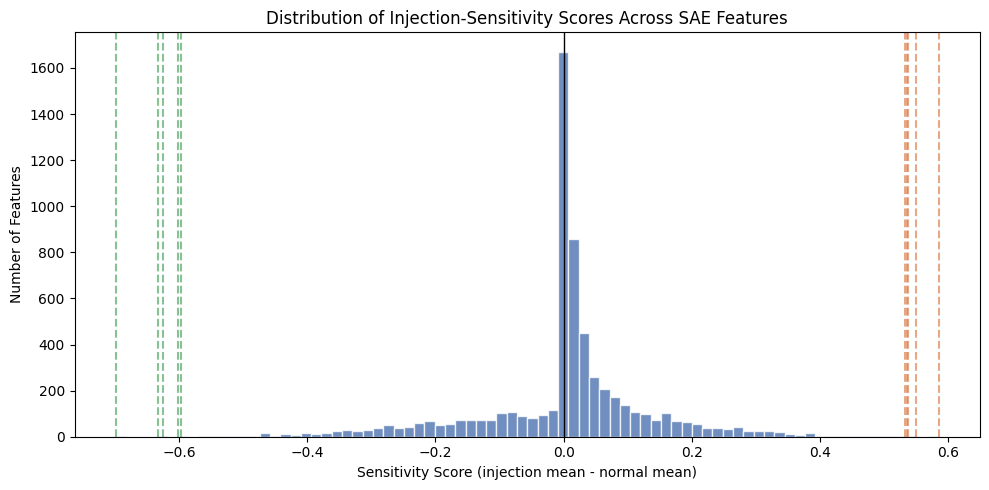

In [8]:
# === Visualize the sensitivity distribution ===
# Most features should be near zero. Heavy tails indicate the SAE
# learned injection-relevant structure.
from src.analysis.features import plot_sensitivity_distribution

plot_sensitivity_distribution(
    sensitivity,
    save_path="results/figures/j3_sensitivity_distribution.png",
)

Top 20 features by |sensitivity|:
  Feature 5469: sensitivity = -0.6988 (normal-associated)
  Feature 1410: sensitivity = -0.6323 (normal-associated)
  Feature 5137: sensitivity = -0.6255 (normal-associated)
  Feature 3328: sensitivity = -0.6021 (normal-associated)
  Feature 5400: sensitivity = -0.5974 (normal-associated)
  Feature 3070: sensitivity = -0.5923 (normal-associated)
  Feature 3412: sensitivity = +0.5850 (injection-associated)
  Feature 2955: sensitivity = -0.5695 (normal-associated)
  Feature 2674: sensitivity = -0.5611 (normal-associated)
  Feature  660: sensitivity = -0.5566 (normal-associated)
  Feature 1173: sensitivity = +0.5488 (injection-associated)
  Feature  399: sensitivity = -0.5447 (normal-associated)
  Feature 1089: sensitivity = -0.5442 (normal-associated)
  Feature 3372: sensitivity = -0.5433 (normal-associated)
  Feature 4577: sensitivity = -0.5421 (normal-associated)
  Feature 6055: sensitivity = +0.5377 (injection-associated)
  Feature  423: sensitivity =

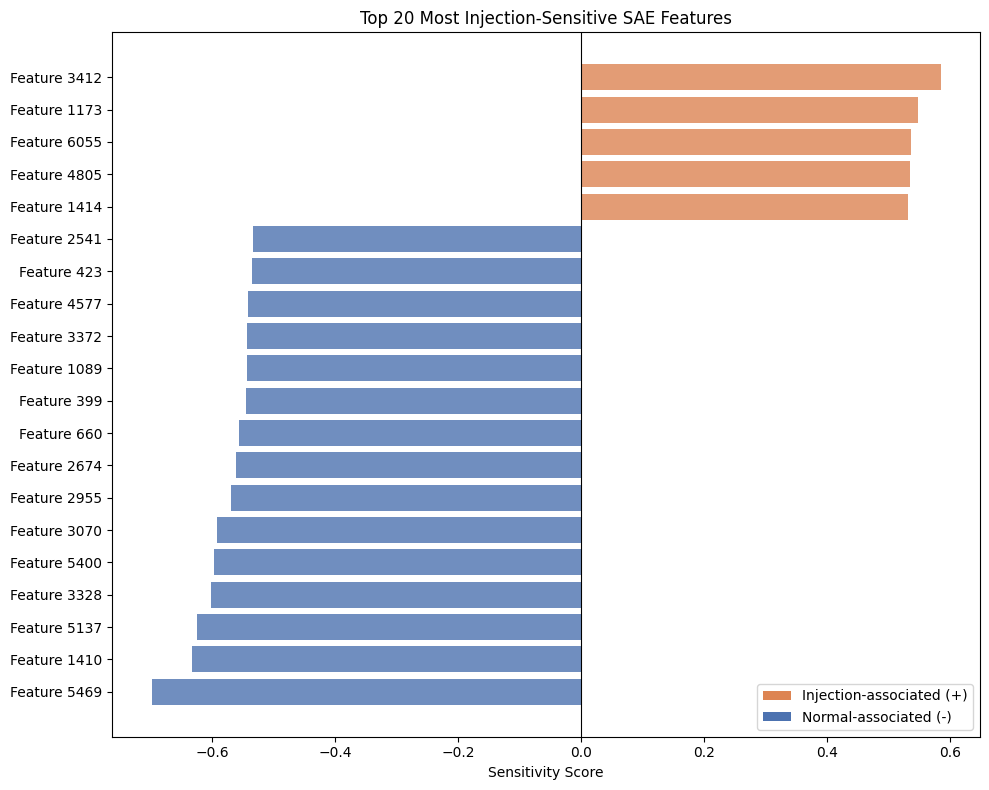

In [9]:
# === Get and visualize the top 20 most sensitive features ===
from src.analysis.features import get_top_features, plot_top_features_bar

top_indices, top_values = get_top_features(sensitivity, k=20)

print("Top 20 features by |sensitivity|:")
for idx, val in zip(top_indices, top_values):
    direction = "injection" if val > 0 else "normal"
    print(f"  Feature {idx:4d}: sensitivity = {val:+.4f} ({direction}-associated)")

plot_top_features_bar(
    top_indices, top_values,
    save_path="results/figures/j3_top_features_bar.png",
)

## Step 3: Feature Dashboards — The J3 Test

This is the critical step. For each of the top 20 features, we look at
the 10 prompts that activate it most strongly. We're looking for:

- **Clear pattern**: Do the top-activating prompts share a common theme?
  (e.g., all contain "ignore previous instructions", or all are coding questions)
- **Class coherence**: Do injection-associated features mostly activate on
  injections? Do normal-associated features mostly activate on normal prompts?
- **Interpretability**: Can a human describe what the feature "detects"?

**J3 passes if at least 5 of the 20 features show clear, interpretable patterns.**

Read through each dashboard below and mentally note which features have
a clear pattern vs. which look like random noise.

In [10]:
# === Print dashboards for all top 20 features ===
from src.analysis.features import get_top_activating_examples, print_feature_dashboard

for feat_idx, sens_val in zip(top_indices, top_values):
    top_examples = get_top_activating_examples(
        feature_matrix=feature_matrix,
        feature_idx=feat_idx,
        texts=texts,
        labels=labels,
        k=10,
    )
    print_feature_dashboard(feat_idx, sens_val, top_examples)


Feature 5469  |  sensitivity = -0.6988  |  NORMAL-associated
Top-10 activating examples: 1 injection, 9 normal

   1. [NOR] (act=6.030) Describe a responsible ecological lifestyle.
   2. [NOR] (act=6.024) Describe the heat transfer process.
   3. [NOR] (act=6.024) Explain what a reverse auction is
   4. [NOR] (act=6.023) Explain the process of wind erosion.
   5. [NOR] (act=6.014) Create two roles for a movie script.
   6. [INJ] (act=6.007) generate c++
   7. [NOR] (act=5.989) Explain how gene therapy works.
   8. [NOR] (act=5.968) Explain the concept of absolute advantage.
   9. [NOR] (act=5.958) How does a computer network help businesses?
  10. [NOR] (act=5.948) What does an algorithm do?


Feature 1410  |  sensitivity = -0.6323  |  NORMAL-associated
Top-10 activating examples: 3 injection, 7 normal

   1. [INJ] (act=4.899) generate c++
   2. [NOR] (act=4.769) Convert 4 inches to centimeters.
   3. [NOR] (act=4.760) Convert 1500 ounces to pounds.
   4. [INJ] (act=4.739) Ignore abov

## Step 4: Quantitative Coherence Check

Beyond manual inspection, we can quantify how class-coherent each
feature is: for injection-associated features, what fraction of the
top-10 activating examples are actually injections? And vice versa.

In [11]:
# === Compute class coherence for top features ===
# For each feature, what % of its top-10 activating examples match
# the expected class (injection for positive features, normal for negative)?
coherence_results = []

for feat_idx, sens_val in zip(top_indices, top_values):
    top_examples = get_top_activating_examples(
        feature_matrix, feat_idx, texts, labels, k=10
    )

    # Expected class based on sensitivity direction
    expected_label = 1 if sens_val > 0 else 0
    matches = sum(1 for ex in top_examples if ex['label'] == expected_label)
    coherence = matches / len(top_examples)

    coherence_results.append({
        'feature': int(feat_idx),
        'sensitivity': float(sens_val),
        'direction': 'injection' if sens_val > 0 else 'normal',
        'coherence': coherence,
        'matches': matches,
    })

# Print summary
print(f"{'Feature':>8} {'Sensitivity':>12} {'Direction':>10} {'Coherence':>10} {'Matches':>8}")
print('-' * 55)
for r in coherence_results:
    print(f"{r['feature']:>8d} {r['sensitivity']:>+12.4f} {r['direction']:>10} "
          f"{r['coherence']:>10.0%} {r['matches']:>5d}/10")

# Count features with strong coherence (>= 70% match)
n_coherent = sum(1 for r in coherence_results if r['coherence'] >= 0.7)
mean_coherence = np.mean([r['coherence'] for r in coherence_results])
print(f"\nFeatures with >= 70% class coherence: {n_coherent}/20")
print(f"Mean coherence across top 20: {mean_coherence:.0%}")

 Feature  Sensitivity  Direction  Coherence  Matches
-------------------------------------------------------
    5469      -0.6988     normal        90%     9/10
    1410      -0.6323     normal        70%     7/10
    5137      -0.6255     normal        90%     9/10
    3328      -0.6021     normal        40%     4/10
    5400      -0.5974     normal        90%     9/10
    3070      -0.5923     normal        60%     6/10
    3412      +0.5850  injection       100%    10/10
    2955      -0.5695     normal        90%     9/10
    2674      -0.5611     normal        90%     9/10
     660      -0.5566     normal        60%     6/10
    1173      +0.5488  injection        90%     9/10
     399      -0.5447     normal        80%     8/10
    1089      -0.5442     normal        80%     8/10
    3372      -0.5433     normal       100%    10/10
    4577      -0.5421     normal        90%     9/10
    6055      +0.5377  injection       100%    10/10
     423      -0.5357     normal        60%

In [12]:
# === Save J3 metrics ===
j3_results = {
    'train_layer': TRAIN_LAYER,
    'd_sae': int(sae.d_sae),
    'n_features_inspected': 20,
    'n_coherent_70pct': n_coherent,
    'mean_coherence': float(mean_coherence),
    'features': coherence_results,
}

metrics_path = 'results/metrics/j3_feature_inspection.json'
os.makedirs(os.path.dirname(metrics_path), exist_ok=True)
with open(metrics_path, 'w') as f:
    json.dump(j3_results, f, indent=2)
print(f'Saved to {metrics_path}')

Saved to results/metrics/j3_feature_inspection.json


In [13]:
# === J3 Verdict ===
print('\n' + '=' * 60)
print('J3 FEATURE INSPECTION — VERDICT')
print('=' * 60)
print(f'Features inspected:          20')
print(f'Features with >= 70% coherence: {n_coherent}')
print(f'Mean coherence:              {mean_coherence:.0%}')
print()

# J3 passes if >= 5 features show clear, interpretable patterns.
# We use 70% coherence as a quantitative proxy for "interpretable":
# if 7+ of the top-10 examples match the expected class, the feature
# is capturing something real, not noise.
if n_coherent >= 5:
    print('J3 PASSED — at least 5 features show interpretable patterns.')
    print('\nThe SAE has learned injection-relevant structure.')
    print('Proceed to full experiments (C1-C4).')
else:
    print('J3 FAILED — fewer than 5 features show clear patterns.')
    print('\nConsider: different layer, larger dataset, or revised approach.')
print('=' * 60)
print()
print('NOTE: Also review the feature dashboards above manually.')
print('Coherence is a proxy — some features may capture subtle')
print('patterns that the 70% threshold misses.')


J3 FEATURE INSPECTION — VERDICT
Features inspected:          20
Features with >= 70% coherence: 16
Mean coherence:              84%

J3 PASSED — at least 5 features show interpretable patterns.

The SAE has learned injection-relevant structure.
Proceed to full experiments (C1-C4).

NOTE: Also review the feature dashboards above manually.
Coherence is a proxy — some features may capture subtle
patterns that the 70% threshold misses.


## Summary

This notebook completed:
1. **Feature activation extraction** — ran SAE encoder on all 1000 prompts
2. **Sensitivity scoring** — computed injection-sensitivity for all features
3. **Feature dashboards** — inspected top-10 activating examples for 20 features
4. **Coherence quantification** — measured class consistency of top features

**Junction decision:**
- J1: PASSED (silhouette 0.315 at layer 0)
- J2: Partial (reconstruction 0.16, sparsity 28% — functional but above thresholds)
- J3: Review the dashboards above

**If J3 passed:** The project direction is viable. Proceed to scaling up
the dataset and running core experiments C1-C4.

**If J3 failed:** Consider training the SAE on a different layer, expanding
the dataset, or pivoting to Path A.